# Devoir CNN "from scratch vs transfert" applique aux jeu de donnees cats and dogs de Kaggle

##### Comparaison **un modèle CNN entraîné from scratch** et **un modèle en transfert d’apprentissage** sur le même jeu de données (cats vs dogs). Montrer l’impact du transfert learning sur la convergence, la performance et la robustesse.

##### METHODE FROM SCRATCH_Definissons un modèle avec au minimum 3 couches de convolution et la propagation avant (feedforward)

#### Importation des bibliotheques necessaires

In [1]:
# Importons les bibliothèques nécessaires
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
#from livelossplot import PlotLosses
#from livelossplot.outputs import MatplotlibPlot
from torch.utils.data.sampler import SubsetRandomSampler
from torchvision import datasets
from tqdm import tqdm
import mlflow
import torch.optim as optim
import multiprocessing
import random
import my_helper
import os
# --- TorchMetrics
from torchmetrics.classification import MulticlassAccuracy, MulticlassConfusionMatrix, BinaryAccuracy, BinaryConfusionMatrix
from torchvision.transforms import v2
import torchvision.transforms as transforms

c:\Users\mok_b\OneDrive\Documents\Formations\FORMATIONS\AI\Deep_learning\DL_PYTORCH\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Ajout des seeds necessaires pour garantir la reproductivite des resultats en fixant toutes les bibliotheques utiles

In [2]:
def set_seed(seed: int=42):

    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"Seed fixée à {seed}")

# Appeler la fonction au début du script
set_seed(42)

Seed fixée à 42


#### Configuration des parametres

In [3]:
params = {
    "project": "cats_dogs_pt",
    "run_name": "devoir_img_tp",
    "data_dir": "data/Cat_Dog_ordered",
    "batch_size": 32,
    "num_workers":4,
    "valid_size": 0.1, 
    "test_size": 0.1,   
    "train_size": 0.8,  
    "lr": 1e-3,
    "epochs": 30,
    "weight_decay": 0.0,
    "model_name": "cats_dogs_cnn",
    "save_path": "best_cats_dogs_model.pt",
}

In [ ]:
#classes=['cat', 'dog']

#### Verification de la bibliotheque disponible

In [4]:
# check if CUDA is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if torch.cuda.is_available():
    print("Entraînement sur GPU (CUDA)")
else:
    print("Entraînement sur CPU") 

Entraînement sur CPU


#### Reamenagement des donnees pour mieux structurer les dossiers data et faciliter le split en train, validation et test

In [5]:
from pathlib import Path
import shutil

# 1. Définition des chemins avec des objets Path (manipulation propre)
source_dir = Path.cwd() / "data" / "Cat_Dog_data"
target_dir = Path.cwd() / "data" / "Cat_Dog_ordered"

# 2. Création des dossiers cibles
for label in ["cat", "dog"]:
    (target_dir / label).mkdir(parents=True, exist_ok=True)

print("Début du déplacement des images...")

# 3. Recherche de tous les fichiers à 3 niveaux de profondeur (*/*/*)
moved_count = 0

for file_path in source_dir.glob("*/*/*"):
    if file_path.is_file():
        # file_path.parts permet d'accéder aux morceaux du chemin sous forme de liste
        label = file_path.parts[-2]
        filename = file_path.name
        
        if label in ["cat", "dog"]:
            subfolder = file_path.parts[-3]
            new_filename = f"{subfolder}_{filename}"
            destination = target_dir / label / new_filename
            
            shutil.move(file_path, destination)
            moved_count += 1

print(f"Terminé ! {moved_count} images ont été déplacées avec succès dans '{target_dir}'.")

Début du déplacement des images...
Terminé ! 0 images ont été déplacées avec succès dans 'c:\Users\mok_b\OneDrive\Documents\Formations\FORMATIONS\AI\Deep_learning\DL_PYTORCH\chapitre 3 cnn\Devoir_scrach_transfert_cnn_Master1\data\Cat_Dog_ordered'.


#### Preparation des fonctions de transformations necessaires pour la DataLoader d'entrainement, de valiation et de test

In [6]:
train_transforms = v2.Compose([
    v2.Resize((224, 224)),
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomRotation(degrees=15),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225])
])
val_test_transforms = v2.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


#### Creation des DataLoaders

In [7]:
import numpy as np
import torch
from torch.utils.data import DataLoader, SubsetRandomSampler
from torchvision import datasets


def get_train_valid_test_data_loaders(data_dir, batch_size, train_size, valid_size, num_workers, train_transforms, val_test_transforms):

    train_dataset = datasets.ImageFolder(data_dir, transform=train_transforms)
    val_test_dataset = datasets.ImageFolder(data_dir, transform=val_test_transforms)

    n_imgs = len(train_dataset)

    # Calcul du nombre d'images pour le train (80%), validation (10%) et test (10%)
    n_train = int(np.floor(train_size * n_imgs))
    n_valid = int(np.floor((train_size + valid_size) * n_imgs))

    # Génération des indices mélangés aléatoirement
    shuffled_indices = torch.randperm(n_imgs)

    # Découpage des indices :
    # - Validation : de 0 à n_valid, - Test : de n_valid à (n_valid + n_test), - Entraînement : le reste (80%)
    train_idx = shuffled_indices[:n_train]
    valid_idx = shuffled_indices[n_train : n_valid]
    test_idx = shuffled_indices[n_valid :]

    # Définition des samplers pour chaque ensemble
    train_sampler = SubsetRandomSampler(train_idx)
    valid_sampler = SubsetRandomSampler(valid_idx)
    test_sampler = SubsetRandomSampler(test_idx)

    # Préparation des DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=train_sampler, num_workers=num_workers,)
    valid_loader = DataLoader(val_test_dataset, batch_size=batch_size, sampler=valid_sampler, num_workers=num_workers,)
    test_loader = DataLoader(val_test_dataset, batch_size=batch_size, sampler=test_sampler, num_workers=num_workers,)

    return train_loader, valid_loader, test_loader


train_dl, valid_dl, test_dl = get_train_valid_test_data_loaders(
    data_dir=params["data_dir"],
    batch_size=params["batch_size"],
    train_size=params["train_size"],
    valid_size=params["valid_size"],
    num_workers=params["num_workers"],
    train_transforms=train_transforms,
    val_test_transforms=val_test_transforms
)

data_loaders = {
    'train': train_dl,
    'val': valid_dl,
    'test': test_dl
}


#### Determination du nombre de DataLoader de train, val et test

In [8]:
print(len(data_loaders["train"]), len(data_loaders["val"]), len(data_loaders["test"]))

625 79 79


In [9]:
classes=data_loaders["train"].dataset.classes

tensor([1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1,
        1, 1, 0, 1, 0, 1, 1, 1])


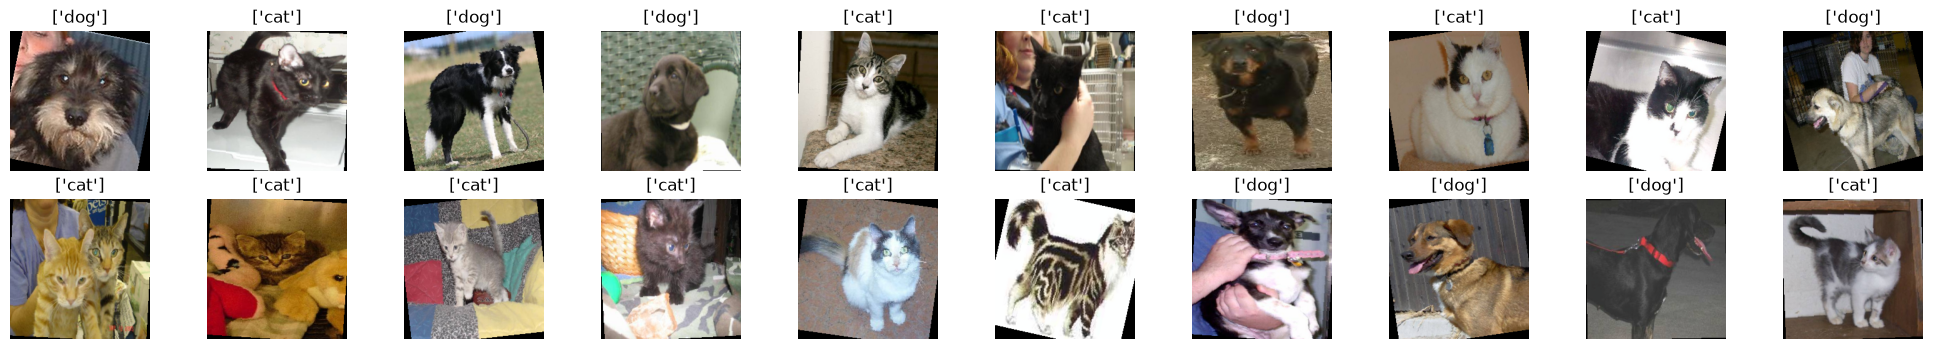

In [10]:
images, labels = next(iter(data_loaders["train"]))
fig, subs = plt.subplots(2, 10, figsize=(25, 4))
print(labels)
for i, sub in enumerate(subs.flatten()):
    my_helper.imshow(images[i], sub)
    sub.set_title([classes[labels[i]]])

In [11]:

import torch.nn as nn
import torch.nn.functional as F

# define the CNN architecture
class MyNet(nn.Module):
    def __init__(self, n_classes=2):

        super(MyNet, self).__init__()

        # YOUR CODE HERE
        # Implementons une convolution de 32 filtres de taille 3*3, Stride = 1, Padding = 1.
        # Taille d'entrée : 224*224*3, Taille de sortie : 224*224*32
        self.conv1=nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.relu1=nn.ReLU()
        # implementons une couche de pooling de taille 2*2, Stride = 2, padding = 0
        self.pool1=nn.MaxPool2d(kernel_size=2, stride=2)  # Taille d'entrée : 224*224*32, Taille de sortie : 112*112*32
        # implementons une convolution de 64 filtres de taille 4*4, Stride = 1, Padding = 2.
        # taille d'entrée : 112*112*32, Taille de sortie : 56*56*64
        self.conv2=nn.Conv2d(in_channels=32, out_channels=64, kernel_size=4, stride=2, padding=1)
        self.relu2=nn.ReLU()
        # implementons une couche de pooling de taille 2*2, Stride = 2, padding = 0
        self.pool2=nn.MaxPool2d(kernel_size=2, stride=2)  # Taille d'entrée : 56*56*64, Taille de sortie : 28*28*64
        # implementons une convolution de 16 filtres de taille 5*5, Stride = 1, Padding = 0.
        # Taille d'entrée : 28*28*64, Taille de sortie : 24*24*16
        self.conv3=nn.Conv2d(in_channels=64, out_channels=16, kernel_size=5, stride=1, padding=0)
        self.relu3=nn.ReLU()
        # implementons une couche de pooling de taille 2*2, Stride = 2, padding = 0
        self.pool3=nn.MaxPool2d(kernel_size=2, stride=2)  # Taille d'entrée : 24*24*16, Taille de sortie : 12*12*16
        # Aplatissons la derniere sortie
        self.flatten=nn.Flatten()
        # Ajoutons une couche linear fully connected de 120 neurones, suivie d'une couche fully connected de 84 neurones, et enfin une couche fully connected de 10 neurones (pour les 10 classes).
        self.fc1=nn.Linear(in_features=12*12*16, out_features=120)
        # Liberons quelaues neurones pour la couche suivante
        self.dropout=nn.Dropout(p=0.3)
        # Appliquons une fonction d'activation non linear ReLU
        self.relu4=nn.ReLU()
        self.fc2=nn.Linear(in_features=120, out_features=84)
        self.relu5=nn.ReLU()
        self.fc3=nn.Linear(in_features=84, out_features=n_classes)


    def forward(self, x):

        # YOUR CODE HERE
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.pool3(self.relu3(self.conv3(x)))
        x = self.flatten(x)
        x =self.dropout(self.relu4(self.fc1(x)))
        x = self.relu5(self.fc2(x))
        x = self.fc3(x)
        return x

# create a complete CNN
model = MyNet()
print(model)

# move tensors to GPU if CUDA is available
model=model.to(device)

MyNet(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 16, kernel_size=(5, 5), stride=(1, 1))
  (relu3): ReLU()
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=2304, out_features=120, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (relu4): ReLU()
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (relu5): ReLU()
  (fc3): Linear(in_features=84, out_features=2, bias=True)
)


In [12]:
# Calculons le nombre de paramètres du modèle
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [13]:
print(f'The model has {count_parameters(model):,} trainable parameters')

The model has 346,278 trainable parameters


#### Enregistrement des experimentations

In [ ]:
# Enregistrement des experimentations 
mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment(params["run_name"])
mlflow.config.enable_system_metrics_logging()

In [15]:
# Definissons les fonctions de pertes et d'optimisation

loss= nn.CrossEntropyLoss()

optimizer=optim.SGD(model.parameters(), lr=0.001)

In [16]:
# TorchMetrics
train_acc = BinaryAccuracy().to(device)
valid_acc = BinaryAccuracy().to(device)
test_acc = BinaryAccuracy().to(device)

#### Chargeons les donnees

In [17]:
# Definissons le chemin du repertoire data et la repartition d'image
data_path = "data/Cat_Dog_data"


#### Entrainons le reseau de neurone

In [18]:
import torch
import torch.nn.functional as F
from tqdm import tqdm
from torchmetrics.classification import MulticlassConfusionMatrix


def train_un_epoch(model, device, loader, optimizer, epoch, acc_metric):
  model.train()
  acc_metric.reset()
  running_loss = 0.0

  for imgs, target in tqdm(loader, desc=f"Training Epoch {epoch}"):
    imgs, target = imgs.to(device), target.to(device)

    optimizer.zero_grad()
    output = model(imgs)
    loss  = F.cross_entropy(output, target)
    loss.backward()
    optimizer.step()

    # Correction 1 : Multiplier par la taille du batch courant
    running_loss += loss.item() * imgs.size(0)

    preds = torch.argmax(output, dim=1)
    acc_metric.update(preds, target)

  epoch_loss = running_loss / len(loader.sampler)
  epoch_acc = acc_metric.compute().item()
  return epoch_loss, epoch_acc 
            

In [19]:
def evaluate(model, loader, criterion, acc_metric):
    model.eval()
    acc_metric.reset()
    running_loss = 0.0

    with torch.no_grad():
        for imgs, targets in tqdm(loader, desc="Valid", ncols=80):
            imgs, targets = imgs.to(device), targets.to(device)
            output = model(imgs)
            loss  = criterion(output, targets)
            running_loss += loss.item() * imgs.size(0)

            preds = torch.argmax(output, dim=1)
            acc_metric.update(preds, targets)

    epoch_loss = running_loss / len(loader.sampler)
    epoch_acc = acc_metric.compute().item()
    return epoch_loss, epoch_acc

In [21]:
# transformons la matrice de confusion (tableau NumPy) en un graphique clair et visuel

def plot_confusion_matrix(cm, classes):
    # Transformation de la matrice NumPy en DataFrame Pandas
    confusion_matrix = pd.DataFrame(cm, index=classes, columns=classes)

    fig, sub = plt.subplots(figsize=(8, 6))

    with sns.plotting_context("notebook"):
        ax = sns.heatmap(
            confusion_matrix,
            annot=True,
            fmt="d",
            ax=sub,
            linewidths=0.5,
            linecolor="lightgray",
            cmap="Blues",
            cbar=False,
        )
        # Belles conventions : Y = Réalité, X = Prédiction
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Ground Truth")
        ax.set_title("Confusion Matrix")

    plt.tight_layout()
    return fig


In [22]:
# exécutons la boucle d'entraînement globale du modèle sur plusieurs époques
best_val = float("inf")
local_save_path = "best_local.pt"

# MLflow remplace wandb.watch en enregistrant directement le modèle PyTorch à la fin
for epoch in range(1, params["epochs"] + 1):
    tr_loss, tr_acc = train_un_epoch(
        model, device, data_loaders["train"], optimizer, epoch, train_acc    )
    val_loss, val_acc = evaluate(
        model, data_loaders["val"], loss, valid_acc
    )

    # 1. Enregistrement des métriques dans MLflow (remplace wandb.log)
    mlflow.log_metrics(
        {
            "train/loss": tr_loss,
            "train/acc": tr_acc,
            "val/loss": val_loss,
            "val/acc": val_acc,
            "lr": optimizer.param_groups[0]["lr"],
        },
        step=epoch,
    )

    print(
        f"Epoch {epoch:02d} | train loss {tr_loss:.4f} train accuracy {tr_acc:.4f} | val loss {val_loss:.4f} val accuracy {val_acc:.4f}"
    )

    # 2. Sauvegarde locale + enregistrement dans MLflow comme artefact
    if val_loss < best_val:
        best_val = val_loss
        print("Enregistrement d'un nouveau best model !")

        # Sauvegarde du fichier local .pt
        torch.save(model.state_dict(), local_save_path)

        # remplace wandb.save(local_save_path)
        mlflow.log_artifact(local_save_path, artifact_path="checkpoints")

        # Optionnel : Enregistrer le modèle au format natif MLflow PyTorch
        mlflow.pytorch.log_model(model, artifact_path="best_model")

Training Epoch 1:   0%|          | 0/625 [00:00<?, ?it/s]

Valid: 100%|████████████████████████████████████| 79/79 [01:11<00:00,  1.11it/s]
2026/09/25 10:01:31 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set logger level to DEBUG for more details.
2026/09/25 10:01:31 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.


Epoch 01 | train loss 0.6929 train accuracy 0.5169 | val loss 0.6926 val accuracy 0.5400
Enregistrement d'un nouveau best model !


2026/09/25 10:01:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/25 10:01:32 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
Valid: 100%|████████████████████████████████████| 79/79 [01:03<00:00,  1.25it/s]
2026/09/25 10:14:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Epoch 02 | train loss 0.6924 train accuracy 0.5394 | val loss 0.6920 val accuracy 0.5876
Enregistrement d'un nouveau best model !


...

Epoch 28 | train loss 0.5797 train accuracy 0.6941 | val loss 0.5699 val accuracy 0.7028
Enregistrement d'un nouveau best model !


2026/09/25 15:23:56 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
Valid: 100%|████████████████████████████████████| 79/79 [01:03<00:00,  1.24it/s]
2026/09/25 15:35:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Epoch 29 | train loss 0.5754 train accuracy 0.6996 | val loss 0.5638 val accuracy 0.7100
Enregistrement d'un nouveau best model !


2026/09/25 15:35:40 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
Valid: 100%|████████████████████████████████████| 79/79 [01:03<00:00,  1.24it/s]

Epoch 30 | train loss 0.5726 train accuracy 0.7004 | val loss 0.5818 val accuracy 0.6916


In [23]:
# Chargeons le meilleurs poids enregistre pendant l'entrainement du modele

model.load_state_dict(torch.load('best_local.pt'))

<All keys matched successfully>

In [24]:
from torchmetrics.classification import BinaryConfusionMatrix

def test_and_confusion(model, loader):
    model.eval()
    # ✅ Aucun argument num_classes n'est requis
    cm = BinaryConfusionMatrix().to(device)

In [25]:
# Evaluons les performances finales du modèle sur le jeu de données de test et de générons sa matrice de confusion.

num_classes = len(classes)
print(f"Nombre de classes : {num_classes}")

# Final test + confusion matrix
print("\nEvaluating on test set …")
cm = test_and_confusion(model, data_loaders["test"]) #num_classes=len(classes))

Nombre de classes : 2

Evaluating on test set …


In [26]:
import torch
from tqdm import tqdm
from torchmetrics.classification import MulticlassConfusionMatrix, MulticlassAccuracy

def test_and_confusion(model, loader, num_classes: int):
    model.eval()
    
    # 1. Initialisation des métriques adaptées au multi-classes
    cm_metric = MulticlassConfusionMatrix(num_classes=num_classes).to(device)
    test_acc = MulticlassAccuracy(num_classes=num_classes).to(device)
    
    with torch.no_grad():
        for imgs, targets in tqdm(loader, desc="Test", ncols=80):
            imgs, targets = imgs.to(device), targets.to(device)
            
            output = model(imgs)
            preds = torch.argmax(output, dim=1)
            
            # 2. Mise à jour des métriques
            cm_metric.update(preds, targets)
            test_acc.update(preds, targets)

    # 3. Calcul final et conversion NumPy
    cm = cm_metric.compute().cpu().numpy().astype(int)
    acc = test_acc.compute().item()
    
    print(f"\nTest Accuracy : {acc * 100:.2f}%")
    
    # 4. Retour de la matrice de confusion (évite l'erreur NoneType)
    return cm

In [27]:
cm = test_and_confusion(model, data_loaders["test"], num_classes=len(classes))

Test: 100%|█████████████████████████████████████| 79/79 [01:03<00:00,  1.25it/s]


Test Accuracy : 71.32%


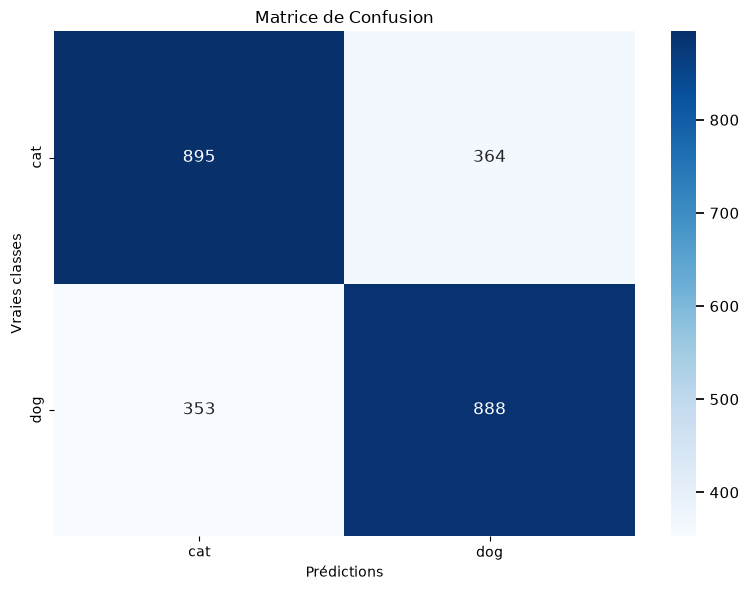

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_matrix(confusion_matrix, classes):
    fig, sub = plt.subplots(figsize=(8, 6))
    
    with sns.plotting_context("notebook"):
        sns.heatmap(
            confusion_matrix,
            annot=True,
            fmt="d",  # "d" pour afficher des entiers
            cmap="Blues",
            xticklabels=classes,
            yticklabels=classes,
            ax=sub
        )
        sub.set_xlabel("Prédictions")
        sub.set_ylabel("Vraies classes")
        sub.set_title("Matrice de Confusion")
    
    plt.tight_layout()
    plt.show()

# Affichage
plot_confusion_matrix(cm, classes)

# Apprentissage par transfert

In [29]:
# Importons les bibliotheques nécessaires
import torchvision.datasets
import torchvision.transforms as T
import torchvision.models
import torch.optim
from torch import nn
import my_helper
import my_helpers
from lr_finder import lr_finder
import glob
import matplotlib.pyplot as plt
from torchvision import models
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms
import torchvision.models as models
import os

In [30]:

train_dl, valid_dl, test_dl = get_train_valid_test_data_loaders(
    data_dir=params["data_dir"],
    batch_size=params["batch_size"],
    train_size=params["train_size"],
    valid_size=params["valid_size"],
    num_workers=params["num_workers"],
    train_transforms=train_transforms,
    val_test_transforms=val_test_transforms
)

data_loaders = {
    'train': train_dl,
    'val': valid_dl,
    'test': test_dl
}


### Creation du model et remplacement de sa tete

In [31]:
model = torchvision.models.resnet50(pretrained=True)

c:\Users\mok_b\OneDrive\Documents\Formations\FORMATIONS\AI\Deep_learning\DL_PYTORCH\.venv\Lib\site-packages\torchvision\models\_utils.py:207: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\mok_b\OneDrive\Documents\Formations\FORMATIONS\AI\Deep_learning\DL_PYTORCH\.venv\Lib\site-packages\torchvision\models\_utils.py:222: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [32]:
# Tete du modele preentraine
model.fc

Linear(in_features=2048, out_features=1000, bias=True)

In [33]:
# Definition des classes
classes=data_loaders["train"].dataset.classes
n_classes = len(classes)
n_inputs = model.fc.in_features 

In [34]:
# Affichage du model
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Con

In [35]:
# Remplacement de la Tête de Classification

# ResNet50 génère un vecteur de 2048 caractéristiques avant sa couche finale
num_features = model.fc.in_features

# Remplacement de la couche finale (cette nouvelle couche a 'requires_grad = True' par défaut)
model.fc = nn.Linear(num_features, num_classes)

model.fc = nn.Sequential(
        nn.Linear(n_inputs, 256),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(256, n_classes))

In [36]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Con

### Gel des parametres du modèle pré-entraîné en dehors de la nouvelle tête de classification

In [37]:
frozen_parameters = []

for p in model.parameters():
    # Geler uniquement les paramètres qui ne le sont pas déjà
    # (le cas échéant)
    if p.requires_grad:
        p.requires_grad = False
        frozen_parameters.append(p)

print(f"{len(frozen_parameters)} groupes de paramètres ont été gelés")

# Maintenant, dégelons les paramètres de la tête que nous avons ajoutée
for p in model.fc.parameters():
    p.requires_grad = True


163 groupes de paramètres ont été gelés


#### Recherche du taux d'apprentissage et entrainement du modele

In [38]:
loss = nn.CrossEntropyLoss()

In [40]:
losses = lr_finder(1e-5, 0.1, 100, loss, model, data_loaders)

Learning rate finder:  16%|███▏                | 99/625 [06:36<35:08,  4.01s/it]


In [41]:
print(losses)

{np.float64(1e-05): 0.6902737021446228, np.float64(1.0974987654930563e-05): 0.6819091737270355, np.float64(1.2045035402587824e-05): 0.6784257094065348, np.float64(1.3219411484660292e-05): 0.6713006943464279, np.float64(1.4508287784959399e-05): 0.6748220920562744, np.float64(1.5922827933410928e-05): 0.6730391979217529, np.float64(1.747528400007684e-05): 0.6753432750701904, np.float64(1.9179102616724892e-05): 0.6806008964776993, np.float64(2.104904144512021e-05): 0.6827221512794495, np.float64(2.3101297000831604e-05): 0.6839186251163483, np.float64(2.5353644939701124e-05): 0.6846881942315535, np.float64(2.7825594022071256e-05): 0.6826630781094233, np.float64(3.053855508833416e-05): 0.6840596153185917, np.float64(3.351602650938844e-05): 0.6822928914002009, np.float64(3.678379771828635e-05): 0.6852786540985106, np.float64(4.037017258596557e-05): 0.6846140585839747, np.float64(4.4306214575838826e-05): 0.6823022716185625, np.float64(4.8626015800653556e-05): 0.6815603541003332, np.float64(5.3

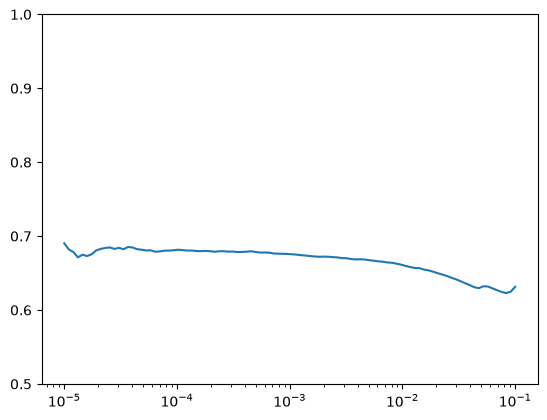

In [42]:
_ = plt.plot(losses.keys(), losses.values())
_ = plt.xscale("log")

# Vous devrez peut-être ajuster cette partie pour couvrir
# correctement l’axe des ordonnées (y) et mieux visualiser
# la diminution de la perte avant qu’elle ne remonte brusquement
_ = plt.ylim([0.5, 1])

#### Entrainement avec 5 epochs

In [43]:

#n_epochs = 5
#lr = 0.1

lr= 1e-4
epochs=5


optimizer = torch.optim.Adam(model.parameters(), lr)

# Représentation sous forme de chaîne de caractères
mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment(params["run_name"])
mlflow.config.enable_system_metrics_logging()

# exécutons la boucle d'entraînement globale du modèle sur plusieurs époques
best_val = float("inf")
local_save_path = "best_transfert.pt"

# MLflow remplace wandb.watch en enregistrant directement le modèle PyTorch à la fin
for epoch in range(1, epochs + 1):
    tr_loss, tr_acc = train_un_epoch(
        model, device, data_loaders["train"], optimizer, epoch, train_acc    )
    val_loss, val_acc = evaluate(
        model, data_loaders["val"], loss, valid_acc
    )

    # 1. Enregistrement des métriques dans MLflow (remplace wandb.log)
    mlflow.log_metrics(
        {
            "train/loss": tr_loss,
            "train/acc": tr_acc,
            "val/loss": val_loss,
            "val/acc": val_acc,
            "lr": optimizer.param_groups[0]["lr"],
        },
        step=epoch,
    )

    print(
        f"Epoch {epoch:02d} | train loss {tr_loss:.4f} train accuracy {tr_acc:.4f} | val loss {val_loss:.4f} val accuracy {val_acc:.4f}"
    )

    # 2. Sauvegarde locale + enregistrement dans MLflow comme artefact
    if val_loss < best_val:
        best_val = val_loss
        print("Enregistrement d'un nouveau best model !")

        # Sauvegarde du fichier local .pt
        torch.save(model.state_dict(), local_save_path)

        # remplace wandb.save(local_save_path)
        mlflow.log_artifact(local_save_path, artifact_path="checkpoints")

        # Optionnel : Enregistrer le modèle au format natif MLflow PyTorch
        mlflow.pytorch.log_model(model, artifact_path="best_model")


Valid: 100%|████████████████████████████████████| 79/79 [04:55<00:00,  3.74s/it]


Epoch 01 | train loss 0.1294 train accuracy 0.9550 | val loss 0.0479 val accuracy 0.9816
Enregistrement d'un nouveau best model !


2026/09/25 16:49:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/25 16:49:40 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
Valid: 100%|████████████████████████████████████| 79/79 [04:24<00:00,  3.35s/it]


Epoch 02 | train loss 0.0847 train accuracy 0.9668 | val loss 0.0643 val accuracy 0.9716


Valid: 100%|████████████████████████████████████| 79/79 [04:54<00:00,  3.73s/it]


...

Epoch 04 | train loss 0.0739 train accuracy 0.9700 | val loss 0.0341 val accuracy 0.9892
Enregistrement d'un nouveau best model !


2026/09/25 19:03:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/25 19:04:01 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
Valid: 100%|████████████████████████████████████| 79/79 [06:06<00:00,  4.64s/it]


Epoch 05 | train loss 0.0738 train accuracy 0.9718 | val loss 0.0331 val accuracy 0.9888
Enregistrement d'un nouveau best model !


2026/09/25 19:56:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/25 19:56:41 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


MlflowException: API request to http://localhost:5000/api/2.0/mlflow-artifacts/artifacts/2/models/m-964b8ae65410413e980a5a673ba538c9/artifacts/data/model.pth failed with exception HTTPConnectionPool(host='localhost', port=5000): Max retries exceeded with url: /api/2.0/mlflow-artifacts/artifacts/2/models/m-964b8ae65410413e980a5a673ba538c9/artifacts/data/model.pth (Caused by ResponseError('too many 500 error responses'))

In [47]:
ct= my_helpers.one_epoch_test(data_loaders['val'], model, loss)

Testing: 100%|██████████████████████████████████| 79/79 [04:30<00:00,  3.43s/it]

Test Loss: 0.032806


Test Accuracy: 98% (2472/2500)


In [49]:
cm = test_and_confusion(model, data_loaders["test"], num_classes=len(classes))

Test: 100%|█████████████████████████████████████| 79/79 [06:15<00:00,  4.76s/it]


Test Accuracy : 98.36%


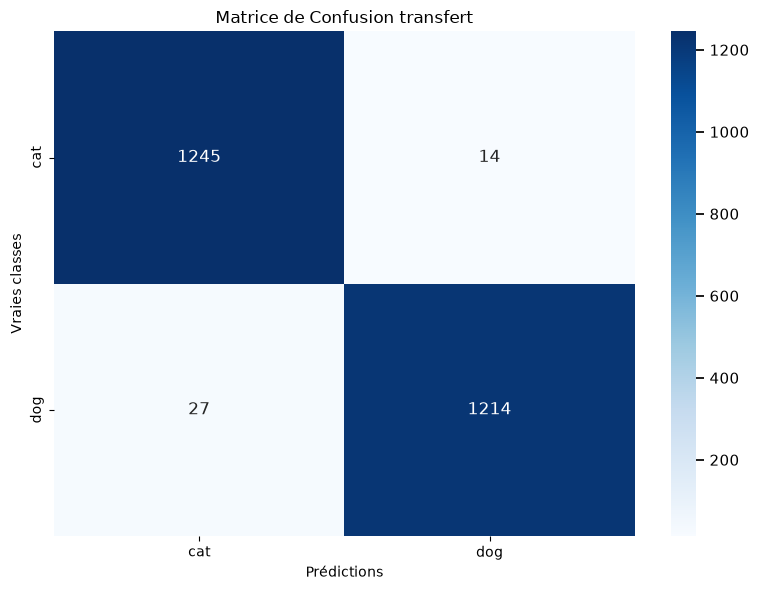

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_matrix(confusion_matrix, classes):
    fig, sub = plt.subplots(figsize=(8, 6))
    
    with sns.plotting_context("notebook"):
        sns.heatmap(
            confusion_matrix,
            annot=True,
            fmt="d",  # "d" pour afficher des entiers
            cmap="Blues",
            xticklabels=classes,
            yticklabels=classes,
            ax=sub
        )
        sub.set_xlabel("Prédictions")
        sub.set_ylabel("Vraies classes")
        sub.set_title("Matrice de Confusion transfert")
    
    plt.tight_layout()
    plt.show()

# Affichage
plot_confusion_matrix(cm, classes)